In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/marieclaudsies/srgan-sar-weights/g_best.pth.tar
/kaggle/input/datasets/marieclaudsies/srgan-sar-weights/d_best.pth.tar
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/inference.py
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/image_quality_assessment.py
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/imgproc.py
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/LICENSE
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/.gitignore
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/test.py
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/model.py
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/README.md
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/utils.py
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/requirements.txt
/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch/dataset.py
/kaggle/input/datasets/marieclaudsies/pyt

In [2]:
import os, subprocess

# See what was extracted
print("=== /kaggle/working/ ===")
for item in os.listdir("/kaggle/working/"):
    print(item)

print("\n=== /kaggle/input/ ===")
for item in os.listdir("/kaggle/input/"):
    print(item)

=== /kaggle/working/ ===
__notebook__.ipynb

=== /kaggle/input/ ===
datasets


In [3]:
import os

def list_all(path, depth=0):
    if depth > 3:
        return
    for item in os.listdir(path):
        print("  " * depth + item)
        full = os.path.join(path, item)
        if os.path.isdir(full):
            list_all(full, depth+1)

list_all("/kaggle/input/")

datasets
  marieclaudsies
    srgan-sar-weights
      g_best.pth.tar
      d_best.pth.tar
    pytorch-1
      SRGAN-PyTorch
    sar-dataset-2-0
      SAR_Dataset


In [4]:
import shutil, os

# Clean up any previous copy
if os.path.exists("/kaggle/working/SRGAN-PyTorch"):
    shutil.rmtree("/kaggle/working/SRGAN-PyTorch")

# Copy project to working directory
shutil.copytree("/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch", 
                "/kaggle/working/SRGAN-PyTorch")

print("Copied! Contents:")
print(os.listdir("/kaggle/working/SRGAN-PyTorch"))

Copied! Contents:
['test.py', '.git', 'README.md', 'model.py', 'scripts', 'utils.py', 'imgproc.py', 'data', 'dataset.py', 'results', 'samples', 'LICENSE', 'inference.py', 'train_gan.py', 'image_quality_assessment.py', 'requirements.txt', 'figure', '.gitignore', 'train_net.py', 'configs']


In [5]:
import subprocess
subprocess.run(
    ["pip", "install", "-r", "/kaggle/working/SRGAN-PyTorch/requirements.txt"],
    check=True
)
print("Requirements installed!")

     ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ 78.6/78.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=78bc84532dd75a80c7756c8045cee1973422f90050e829bd13ef6c3a3b80894f
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing
Requirements installed!


In [6]:
train_gan_path = "/kaggle/working/SRGAN-PyTorch/train_gan.py"

with open(train_gan_path) as f:
    content = f.read()

old_save = """        # Automatically save model weights
        is_best = psnr > best_psnr and ssim > best_ssim
        is_last = (epoch + 1) == config["TRAIN"]["HYP"]["EPOCHS"]
        best_psnr = max(psnr, best_psnr)
        best_ssim = max(ssim, best_ssim)
        save_checkpoint({"epoch": epoch + 1,"""

new_save = """        # Automatically save model weights
        is_best = psnr > best_psnr and ssim > best_ssim
        is_last = (epoch + 1) == config["TRAIN"]["HYP"]["EPOCHS"]
        is_milestone = (epoch + 1) % 10 == 0
        best_psnr = max(psnr, best_psnr)
        best_ssim = max(ssim, best_ssim)
        if not (is_best or is_last or is_milestone):
            continue
        save_checkpoint({"epoch": epoch + 1,"""

content = content.replace(old_save, new_save)

with open(train_gan_path, "w") as f:
    f.write(content)

# Verify
with open(train_gan_path) as f:
    lines = f.readlines()

print("Verifying change (lines 173-180):")
for i, line in enumerate(lines[171:181], 172):
    print(f"{i:4}: {line}", end="")

Verifying change (lines 173-180):
 172: 
 173:         # Automatically save model weights
 174:         is_best = psnr > best_psnr and ssim > best_ssim
 175:         is_last = (epoch + 1) == config["TRAIN"]["HYP"]["EPOCHS"]
 176:         is_milestone = (epoch + 1) % 10 == 0
 177:         best_psnr = max(psnr, best_psnr)
 178:         best_ssim = max(ssim, best_ssim)
 179:         if not (is_best or is_last or is_milestone):
 180:             continue
 181:         save_checkpoint({"epoch": epoch + 1,


### Train and print for every 10 epochs

In [8]:
import yaml
path = "/kaggle/working/SRGAN-PyTorch/configs/train/SRGAN_x4-ImageNet.yaml"
with open(path) as f:
    config = yaml.full_load(f)

# Fix all paths to Kaggle paths
config["TRAIN"]["DATASET"]["TRAIN_GT_IMAGES_DIR"] = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_HR"
config["TEST"]["DATASET"]["PAIRED_TEST_GT_IMAGES_DIR"] = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_HR"
config["TEST"]["DATASET"]["PAIRED_TEST_LR_IMAGES_DIR"] = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_LR"
config["TEST"]["SAVE_IMAGE_DIR"] = "/kaggle/working/SRGAN-PyTorch/results/test_images"
config["TRAIN"]["CHECKPOINT"]["PRETRAINED_G_MODEL"] = ""
config["TRAIN"]["CHECKPOINT"]["PRETRAINED_D_MODEL"] = ""
config["TRAIN"]["HYP"]["EPOCHS"] = 100

with open(path, "w") as f:
    yaml.dump(config, f, default_flow_style=False)

# Verify
print("Train HR  :", config["TRAIN"]["DATASET"]["TRAIN_GT_IMAGES_DIR"])
print("Test GT   :", config["TEST"]["DATASET"]["PAIRED_TEST_GT_IMAGES_DIR"])
print("Test LR   :", config["TEST"]["DATASET"]["PAIRED_TEST_LR_IMAGES_DIR"])
print("Save dir  :", config["TEST"]["SAVE_IMAGE_DIR"])
print("Epochs    :", config["TRAIN"]["HYP"]["EPOCHS"])
print("Pretrained:", config["TRAIN"]["CHECKPOINT"]["PRETRAINED_G_MODEL"])

# Add milestone PSNR/SSIM printing to train_gan.py
train_gan_path = "/kaggle/working/SRGAN-PyTorch/train_gan.py"

with open(train_gan_path) as f:
    content = f.read()

old_metrics = """        is_best = psnr > best_psnr and ssim > best_ssim
        is_last = (epoch + 1) == config["TRAIN"]["HYP"]["EPOCHS"]
        is_milestone = (epoch + 1) % 10 == 0"""

new_metrics = """        is_best = psnr > best_psnr and ssim > best_ssim
        is_last = (epoch + 1) == config["TRAIN"]["HYP"]["EPOCHS"]
        is_milestone = (epoch + 1) % 10 == 0
        if is_milestone or is_last:
            print(f">>> Epoch [{epoch + 1}/{config['TRAIN']['HYP']['EPOCHS']}] "
                  f"PSNR: {psnr:.4f} dB | SSIM: {ssim:.4f} | Best PSNR: {best_psnr:.4f}")"""

content = content.replace(old_metrics, new_metrics)

with open(train_gan_path, "w") as f:
    f.write(content)

# Verify
with open(train_gan_path) as f:
    lines = f.readlines()

print("\nVerifying milestone print (lines 174-182):")
for i, line in enumerate(lines[172:183], 173):
    print(f"{i:4}: {line}", end="")


Train HR  : /kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_HR
Test GT   : /kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_HR
Test LR   : /kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_LR
Save dir  : /kaggle/working/SRGAN-PyTorch/results/test_images
Epochs    : 100
Pretrained: 

Verifying milestone print (lines 174-182):
 173:         # Automatically save model weights
 174:         is_best = psnr > best_psnr and ssim > best_ssim
 175:         is_last = (epoch + 1) == config["TRAIN"]["HYP"]["EPOCHS"]
 176:         is_milestone = (epoch + 1) % 10 == 0
 177:         if is_milestone or is_last:
 178:             print(f">>> Epoch [{epoch + 1}/{config['TRAIN']['HYP']['EPOCHS']}] "
 179:                   f"PSNR: {psnr:.4f} dB | SSIM: {ssim:.4f} | Best PSNR: {best_psnr:.4f}")
 180:         best_psnr = max(psnr, best_psnr)
 181:         best_ssim = max(ssim, best_ssim)
 182:         if not (is_best or is_last or is_mile

In [9]:
import subprocess
result = subprocess.run(
    ["python", "train_gan.py", "--config_path", "./configs/train/SRGAN_x4-ImageNet.yaml"],
    cwd="/kaggle/working/SRGAN-PyTorch"
)

2026-03-30 11:52:54.368634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774871574.573484      65 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774871574.632954      65 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774871575.125101      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774871575.125155      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774871575.125158      65 computation_placer.cc:177] computation placer alr

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿| 548M/548M [00:02<00:00, 213MB/s]
/kaggle/working/SRGAN-PyTorch/train_gan.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/kaggle/working/SRGAN-PyTorch/model.py:328: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses = torch.Tensor([losses]).to(device)
/kaggle/working/SRGAN-PyTorch/train_gan.py:464: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/kaggle/working/SRGAN-PyTorch/train_gan.py:472: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Pretrained g model weights not found.
Pretrained dd model weights not found.
Resume training g model not found. Start training from scratch.
Resume training d model not found. Start training from scratch.
Epoch: [1][  0/402]	Time 13.538 (13.538)	Data  0.273 ( 0.273)	G Loss 0.698580 (0.698580)	D Loss 1.369461 (1.369461)
Epoch: [1][100/402]	Time  0.112 ( 0.276)	Data  0.002 ( 0.029)	G Loss 0.476854 (0.611540)	D Loss 0.002055 (0.550534)
Epoch: [1][200/402]	Time  0.110 ( 0.214)	Data  0.003 ( 0.032)	G Loss 0.393245 (0.520482)	D Loss 0.038425 (0.410606)
Epoch: [1][300/402]	Time  0.119 ( 0.192)	Data  0.002 ( 0.032)	G Loss 0.355731 (0.469548)	D Loss 0.015596 (0.347007)
Epoch: [1][400/402]	Time  0.094 ( 0.182)	Data  0.001 ( 0.032)	G Loss 0.323521 (0.439237)	D Loss 0.927222 (0.375211)
Test: [   0/6435]	Time  0.524 ( 0.524)	PSNR 17.68 (17.68)	SSIM 0.3032 (0.3032)
Test: [ 100/6435]	Time  0.016 ( 0.020)	PSNR 18.59 (19.72)	SSIM 0.2016 (0.2357)
Test: [ 200/6435]	Time  0.016 ( 0.018)	PSNR 18.90 (19.58)

In [10]:
import shutil, os

os.makedirs("/kaggle/working/final_weights", exist_ok=True)

shutil.copy(
    "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_best.pth.tar",
    "/kaggle/working/final_weights/g_best.pth.tar"
)
shutil.copy(
    "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/d_best.pth.tar",
    "/kaggle/working/final_weights/d_best.pth.tar"
)
print("Both weights saved to /kaggle/working/final_weights/!")

Both weights saved to /kaggle/working/final_weights/!


### TEST PHASE

In [11]:
import shutil, os

# Find the weights path
for root, dirs, files in os.walk("/kaggle/input/"):
    for f in files:
        if "srgan-sar" in root.lower() or "weights" in root.lower():
            print(os.path.join(root, f))

/kaggle/input/datasets/marieclaudsies/srgan-sar-weights/g_best.pth.tar
/kaggle/input/datasets/marieclaudsies/srgan-sar-weights/d_best.pth.tar


In [12]:
import shutil, os

# Copy project
if os.path.exists("/kaggle/working/SRGAN-PyTorch"):
    shutil.rmtree("/kaggle/working/SRGAN-PyTorch")
shutil.copytree("/kaggle/input/datasets/marieclaudsies/pytorch-1/SRGAN-PyTorch", 
                "/kaggle/working/SRGAN-PyTorch")

# Copy trained weights
os.makedirs("/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet", exist_ok=True)
shutil.copy(
    "/kaggle/input/datasets/marieclaudsies/srgan-sar-weights/g_best.pth.tar",
    "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_best.pth.tar"
)

print("Done! Weight size:", os.path.getsize("/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_best.pth.tar") / (1024*1024), "MB")

Done! Weight size: 23.89271640777588 MB


In [13]:
import subprocess, os

lr_dir = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_LR"
test_image = os.path.join(lr_dir, os.listdir(lr_dir)[0])

os.makedirs("/kaggle/working/sr_output", exist_ok=True)

result = subprocess.run([
    "python", "inference.py",
    "--inputs", test_image,
    "--output", "/kaggle/working/sr_output/sr_result.png",
    "--model_arch_name", "srresnet_x4",
    "--model_weights_path", "./results/SRGAN_x4-ImageNet/g_best.pth.tar",
    "--device", "cuda:0"
], cwd="/kaggle/working/SRGAN-PyTorch", capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

STDOUT: Build `srresnet_x4` model successfully.
Load `srresnet_x4` model weights `/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_best.pth.tar` successfully.
SR image save to `/kaggle/working/sr_output/sr_result.png`

STDERR: 
Return code: 0


SR file exists: True
SR file size: 161073 bytes
LR image shape: (64, 64, 3)
SR image shape: (256, 256, 3)


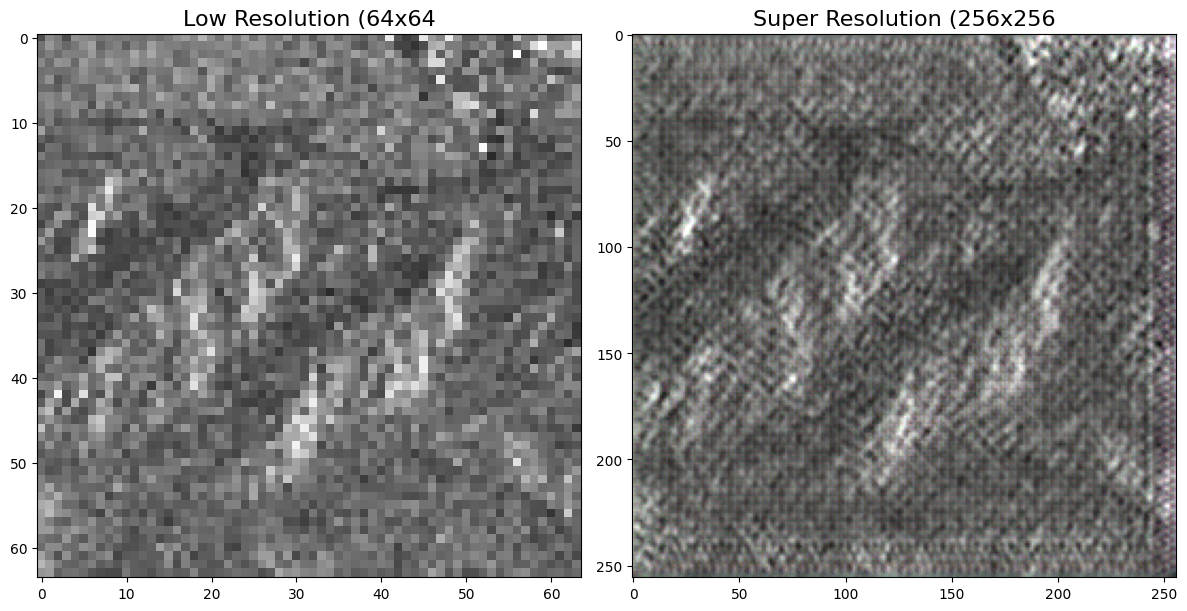

In [14]:
import matplotlib.pyplot as plt
import cv2, os

lr_dir = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_LR"
test_image = os.path.join(lr_dir, os.listdir(lr_dir)[0])

# Check file exists and size
sr_path = "/kaggle/working/sr_output/sr_result.png"
print("SR file exists:", os.path.exists(sr_path))
print("SR file size:", os.path.getsize(sr_path), "bytes")

lr_img = cv2.imread(test_image)
sr_img = cv2.imread(sr_path)

print("LR image shape:", lr_img.shape)
print("SR image shape:", sr_img.shape if sr_img is not None else "None - failed to read!")

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Low Resolution ({lr_img.shape[1]}x{lr_img.shape[0]}",fontsize=16)

if sr_img is not None:
    axes[1].imshow(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Super Resolution ({sr_img.shape[1]}x{sr_img.shape[0]}",fontsize=16)
else:
    axes[1].set_title("Failed to load SR image")

plt.tight_layout()
plt.savefig("/kaggle/working/sr_output/comparison.png")
plt.show()

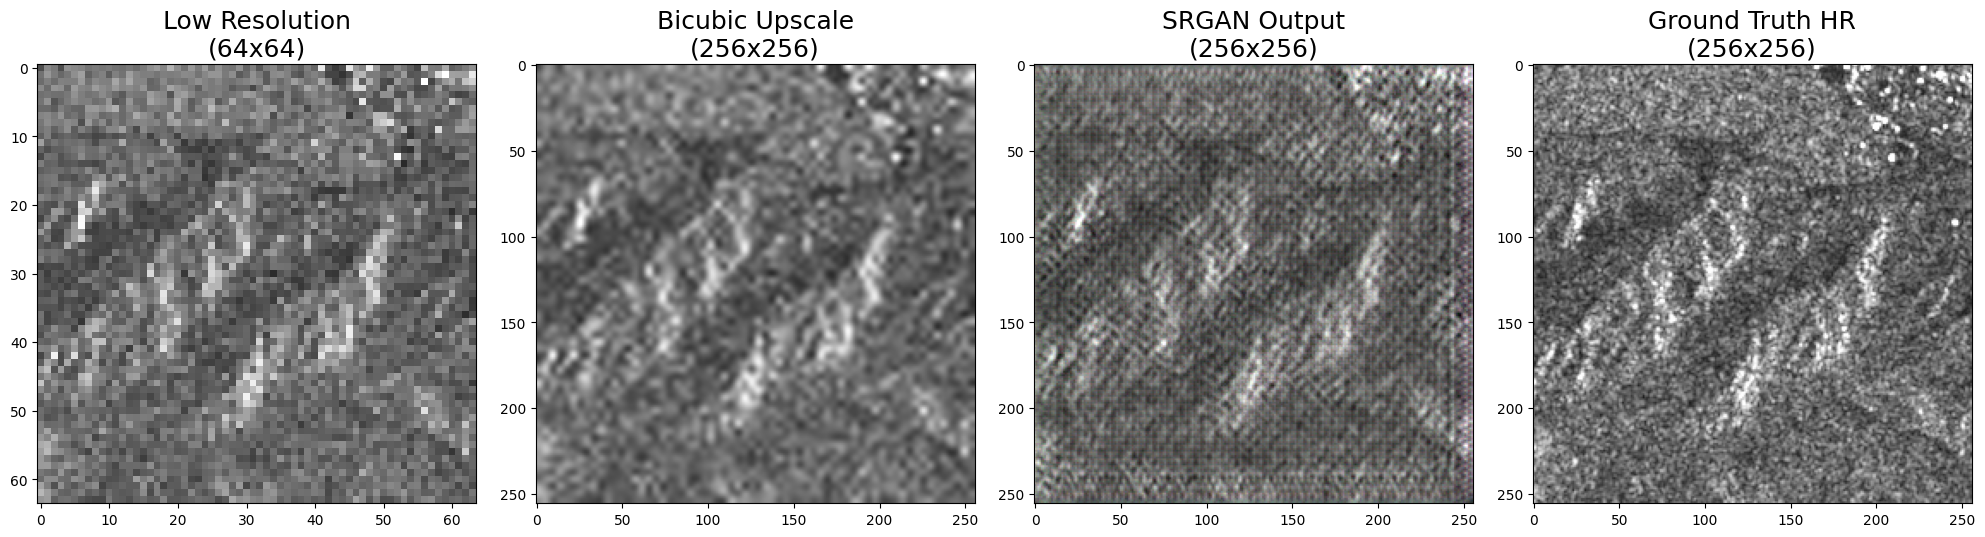

In [15]:
import matplotlib.pyplot as plt
import cv2, os

lr_dir = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_LR"
hr_dir = "/kaggle/input/datasets/marieclaudsies/sar-dataset-2-0/SAR_Dataset/train_HR"

# Use same filename in both folders
filename = os.listdir(lr_dir)[0]
lr_img = cv2.imread(os.path.join(lr_dir, filename))
hr_img = cv2.imread(os.path.join(hr_dir, filename))
sr_img = cv2.imread("/kaggle/working/sr_output/sr_result.png")

# Bicubic upscale for comparison
bicubic_img = cv2.resize(lr_img, (256, 256), interpolation=cv2.INTER_CUBIC)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Low Resolution\n(64x64)", fontsize=18)
axes[1].imshow(cv2.cvtColor(bicubic_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Bicubic Upscale\n(256x256)",fontsize=18)
axes[2].imshow(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
axes[2].set_title("SRGAN Output\n(256x256)",fontsize=18)
axes[3].imshow(cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB))
axes[3].set_title("Ground Truth HR\n(256x256)",fontsize=18)

plt.tight_layout()
plt.savefig("/kaggle/working/sr_output/full_comparison.png", dpi=150)
plt.show()